# Multiple Instance Learning

In [1]:
#from models import MIL_model, MLP_encoder, MaxAggergation, AttentionAggregation, GatedAttentionAggregation
import models
from training_utils import model_run, set_seed
from evaluation_utils import evaluate_accuracy
from CustomDataloader import CustomLoader
from CellsData import CellsData

from mil import PROJECT_ROOT

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

import importlib

sns.set_theme()

In [2]:
# Set to True if you want to use original sparse matrix data, False if you want low dimensional embeddings
use_sparse_data = True


if use_sparse_data:
    input_size = 2000
    bag_key = 'bag'
    num_epochs_master = 30
else:
    input_size = 30
    bag_key = 'bag_embed'
    num_epochs_master = 30

In [3]:
train_set = CellsData(split="train")
val_set = CellsData(split="val")
test_set = CellsData(split="test")

n_bags = sum([len(el) for el in (train_set, val_set, test_set)])
print(f"The entire datatset contains {n_bags} bags.")

train_loader = CustomLoader(train_set, batchsize=20)
validation_loader = CustomLoader(val_set, batchsize=20)
test_loader = CustomLoader(test_set, batchsize=20)

The entire datatset contains 146 bags.


## Maximum aggregation

Epoch 1/20, Train Loss: 0.3596, Validation Loss: 0.3576
Epoch 2/20, Train Loss: 0.3477, Validation Loss: 0.3562
Epoch 3/20, Train Loss: 0.3413, Validation Loss: 0.3455
Epoch 4/20, Train Loss: 0.3417, Validation Loss: 0.3454
Epoch 5/20, Train Loss: 0.3406, Validation Loss: 0.3492
Epoch 6/20, Train Loss: 0.3344, Validation Loss: 0.3441
Epoch 7/20, Train Loss: 0.3345, Validation Loss: 0.3422
Epoch 8/20, Train Loss: 0.3291, Validation Loss: 0.3277
Epoch 9/20, Train Loss: 0.3225, Validation Loss: 0.3652
Epoch 10/20, Train Loss: 0.3198, Validation Loss: 0.3233
Epoch 11/20, Train Loss: 0.3154, Validation Loss: 0.3738
Epoch 12/20, Train Loss: 0.3058, Validation Loss: 0.3540
Epoch 13/20, Train Loss: 0.2951, Validation Loss: 0.3791
Epoch 14/20, Train Loss: 0.2833, Validation Loss: 0.3309
Epoch 15/20, Train Loss: 0.2899, Validation Loss: 0.3610
Epoch 16/20, Train Loss: 0.2649, Validation Loss: 0.5302
Epoch 17/20, Train Loss: 0.2426, Validation Loss: 0.3088
Epoch 18/20, Train Loss: 0.2542, Validat

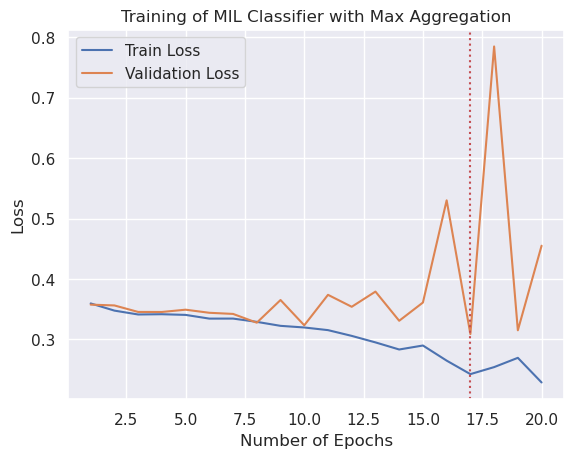

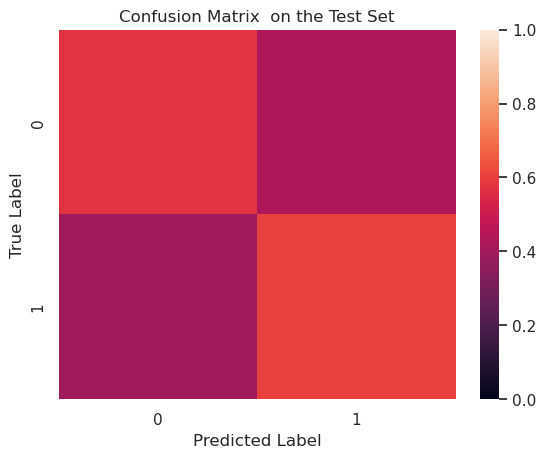

In [28]:
importlib.reload(models)


if use_sparse_data:
    n_hidden = 3
    hidden_size = 10
    lr = 10**-2
    decay = 10**-2
    encoding_size = 10
    seed = 37
else:
    n_hidden = 1
    hidden_size = 30#30
    lr = 10**-2
    decay = 10**-1.7005985187830885
    seed = 27#27
    encoding_size = 30 #30

set_seed(seed)


table_row_to_number = models.MLP_encoder(
    n_hidden=n_hidden, hidden_size=hidden_size, output_size=encoding_size, input_size=input_size
)
max_aggregator = models.MaxAggergation(post_process=True, encoding_size=encoding_size)

model = models.MIL_model(instance_encoder=table_row_to_number, bag_aggregator=max_aggregator)


criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=decay, weight_decay=decay)

num_epochs = 20#num_epochs_master


fig, ax = plt.subplots()


path_prefix = PROJECT_ROOT / "data/max_aggregation_models/epoch_"
train_loss, valid_loss, best_epoch = model_run(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    save_path_prefix=str(path_prefix),
    ax=ax,
    plot_title="Training of MIL Classifier with Max Aggregation",
    sparse=use_sparse_data,
)


best_epoch = 16
path = str(path_prefix) + f"{best_epoch}.torch"
model = torch.load(path)


evaluate_accuracy(model=model, dataset=test_set, bag_key = bag_key, mode = 'Test')

## Attention Aggregation

Epoch 1/20, Train Loss: 0.3589, Validation Loss: 0.3449
Epoch 2/20, Train Loss: 0.3436, Validation Loss: 0.3493
Epoch 3/20, Train Loss: 0.3354, Validation Loss: 0.3510
Epoch 4/20, Train Loss: 0.3322, Validation Loss: 0.3553
Epoch 5/20, Train Loss: 0.3277, Validation Loss: 0.3506
Epoch 6/20, Train Loss: 0.3271, Validation Loss: 0.3436
Epoch 7/20, Train Loss: 0.3237, Validation Loss: 0.3557
Epoch 8/20, Train Loss: 0.3184, Validation Loss: 0.3437
Epoch 9/20, Train Loss: 0.3105, Validation Loss: 0.3487
Epoch 10/20, Train Loss: 0.3044, Validation Loss: 0.3471
Epoch 11/20, Train Loss: 0.3004, Validation Loss: 0.3466
Epoch 12/20, Train Loss: 0.2923, Validation Loss: 0.3477
Epoch 13/20, Train Loss: 0.2924, Validation Loss: 0.3453
Epoch 14/20, Train Loss: 0.2775, Validation Loss: 0.3614
Epoch 15/20, Train Loss: 0.2776, Validation Loss: 0.3735
Epoch 16/20, Train Loss: 0.2573, Validation Loss: 0.3549
Epoch 17/20, Train Loss: 0.2505, Validation Loss: 0.3863
Epoch 18/20, Train Loss: 0.2434, Validat

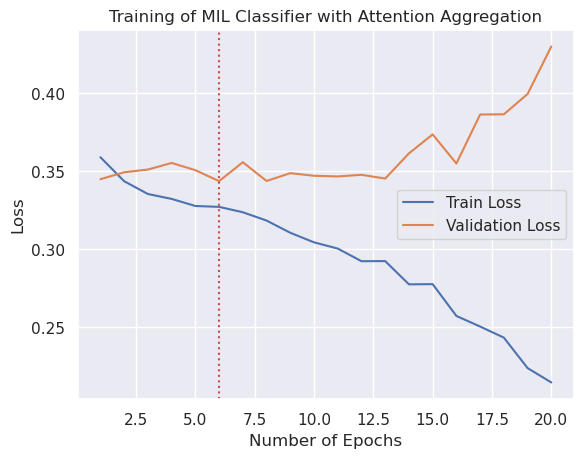

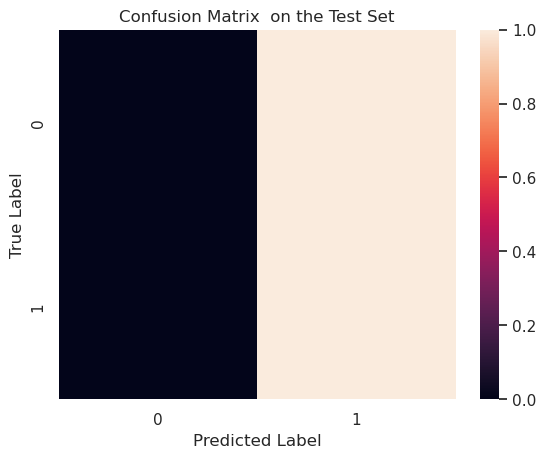

In [83]:
importlib.reload(models)

if use_sparse_data:
    encoding_size = 10
    attention_hidden_size = 10
    hidden_size = 10
    lr = 10**-3
    decay = 10**-2
    n_hidden = 3
    seed = 2023
      
    
else:
    encoding_size = 14
    attention_hidden_size = 14
    hidden_size = 36
    lr = 10**-1.8
    decay = 10**-1
    n_hidden = 3
    seed = 42

    encoding_size = 40
    attention_hidden_size = 10
    hidden_size = 40
    lr = 10**-2
    decay = 10**-2
    n_hidden = 3
    seed = 42

set_seed(seed)
table_row_to_vector = models.MLP_encoder(
    n_hidden=n_hidden, hidden_size=hidden_size, output_size=encoding_size, input_size=input_size)
attention_aggregator = models.AttentionAggregation(
    encoding_size=encoding_size, attention_hidden_size=attention_hidden_size)

model = models.MIL_model(instance_encoder=table_row_to_vector,
                  bag_aggregator=attention_aggregator)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=decay)

num_epochs = 20#num_epochs_master

fig, ax = plt.subplots()

path_prefix = PROJECT_ROOT / "data/attention_aggregation_models/epoch_"
train_loss, valid_loss, best_epoch = model_run(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    save_path_prefix=str(path_prefix),
    ax=ax,
    plot_title="Training of MIL Classifier with Attention Aggregation",
    sparse=use_sparse_data
)

path = str(path_prefix) + f"{best_epoch}.torch"
model = torch.load(path)


evaluate_accuracy(model=model, dataset=test_set, bag_key = bag_key, mode='Test')


Accuracy: 54.55%
Balanced Accuracy: 54.55%


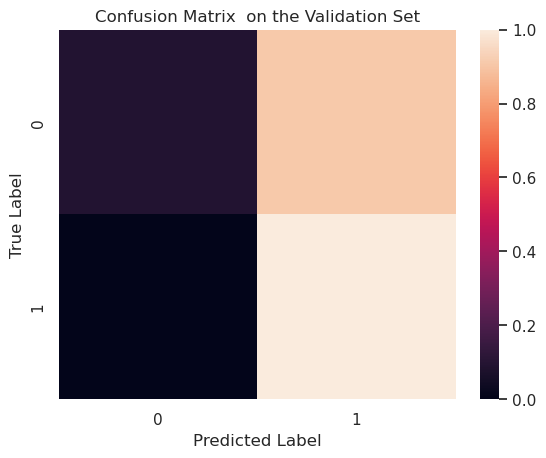

In [55]:
import importlib
import evaluation_utils
importlib.reload(evaluation_utils)
evaluation_utils.evaluate_accuracy(model=model, dataset=val_set, bag_key='bag')

## Gated Attention Aggregation

Epoch 1/20, Train Loss: 0.5494, Validation Loss: 0.3392
Epoch 2/20, Train Loss: 0.3755, Validation Loss: 0.5595
Epoch 3/20, Train Loss: 0.4028, Validation Loss: 0.3450
Epoch 4/20, Train Loss: 0.3600, Validation Loss: 0.3457
Epoch 5/20, Train Loss: 0.3272, Validation Loss: 0.3313
Epoch 6/20, Train Loss: 0.3131, Validation Loss: 0.3014
Epoch 7/20, Train Loss: 0.3179, Validation Loss: 0.2962
Epoch 8/20, Train Loss: 0.2912, Validation Loss: 0.3573
Epoch 9/20, Train Loss: 0.2814, Validation Loss: 0.3012
Epoch 10/20, Train Loss: 0.2729, Validation Loss: 0.4692
Epoch 11/20, Train Loss: 0.2716, Validation Loss: 0.3154
Epoch 12/20, Train Loss: 0.2940, Validation Loss: 0.4176
Epoch 13/20, Train Loss: 0.2151, Validation Loss: 0.3625
Epoch 14/20, Train Loss: 0.2162, Validation Loss: 0.3914
Epoch 15/20, Train Loss: 0.1761, Validation Loss: 0.9213
Epoch 16/20, Train Loss: 0.3267, Validation Loss: 0.3920
Epoch 17/20, Train Loss: 0.2618, Validation Loss: 0.5785
Epoch 18/20, Train Loss: 0.1993, Validat

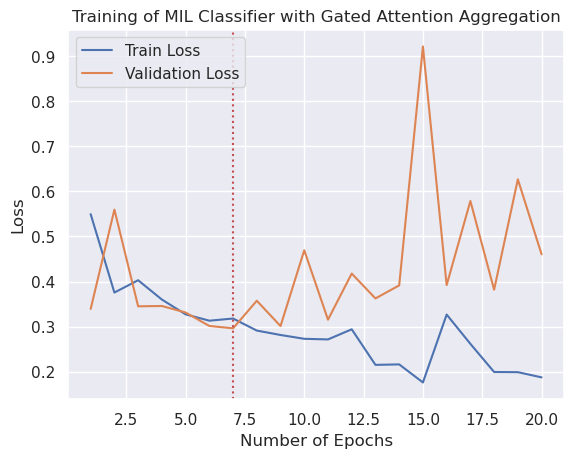

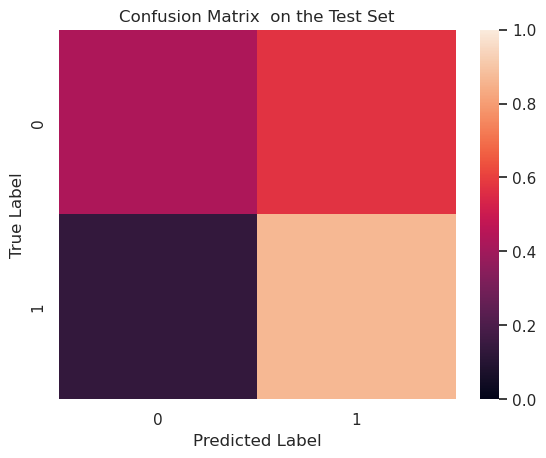

In [73]:
import models
import importlib
importlib.reload(models)


if use_sparse_data:
    encoding_size = 10
    attention_hidden_size = 10
    hidden_size = 20
    lr = 10**-2
    decay = 10**-2
    n_hidden = 3
    seed = 0
    
else:
    encoding_size = 4
    attention_hidden_size = 42
    hidden_size = 43
    lr = 10**-2
    decay = 10**-2
    n_hidden = 2
    seed = 0





set_seed(seed)
table_row_to_vector = models.MLP_encoder(
    n_hidden=n_hidden, hidden_size=hidden_size, output_size=encoding_size, input_size=input_size)
attention_aggregator = models.GatedAttentionAggregation(
    encoding_size=encoding_size, attention_hidden_size=attention_hidden_size)

model = models.MIL_model(instance_encoder=table_row_to_vector,
                  bag_aggregator=attention_aggregator)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=decay)

num_epochs = 20#num_epochs_master
    
fig, ax = plt.subplots()

path_prefix = PROJECT_ROOT / "data/gated_attention_aggregation_models/epoch_"
train_loss, valid_loss, best_epoch = model_run(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    save_path_prefix=str(path_prefix),
    ax=ax,
    plot_title="Training of MIL Classifier with Gated Attention Aggregation",
    sparse=use_sparse_data
)

path = str(path_prefix) + f"{best_epoch}.torch"
model = torch.load(path)


evaluate_accuracy(model=model, dataset=test_set, bag_key = bag_key, mode = 'Test')


Accuracy: 50.00%
Balanced Accuracy: 56.03%


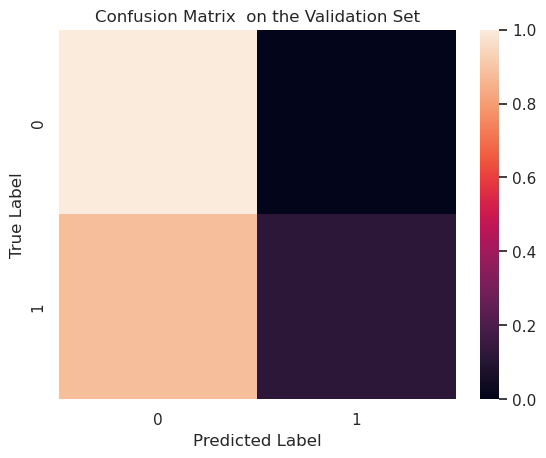

In [68]:
evaluate_accuracy(model=model, dataset=train_set, bag_key = bag_key)